In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model
from xgboost import XGBRegressor

# Explainability
import shap

# Saving model
import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("../data/icu_data.csv")

print("Dataset Loaded Successfully")

print(df.shape)

Dataset Loaded Successfully
(104557, 67)


In [4]:
print("Before Removing Duplicates:")
print(df.shape)

df = df.drop_duplicates()

print("\nAfter Removing Duplicates:")
print(df.shape)

Before Removing Duplicates:
(104557, 67)

After Removing Duplicates:
(104557, 67)


In [5]:
df = df[df["EstimatedLengthOfStay"] >= 0]

print("After Removing Negative LOS:")
print(df.shape)

After Removing Negative LOS:
(103248, 67)


In [6]:
drop_cols = [
    "ID",
    "UHID",
    "IPNumber",
    "ICUChartDate",
    "EstimatedMortalityRate",
    "UpdatedBy",
    "UpdatedDate",
    "Ward"
]

drop_cols = [col for col in drop_cols if col in df.columns]

df.drop(columns=drop_cols, inplace=True)

print("Dropped Columns:")
print(drop_cols)

print("\nUpdated Shape:")
print(df.shape)

Dropped Columns:
['ID', 'UHID', 'IPNumber', 'ICUChartDate', 'EstimatedMortalityRate', 'UpdatedBy', 'UpdatedDate', 'Ward']

Updated Shape:
(103248, 59)


In [7]:
missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print(missing_values)

DISCHARGEDATE     11764
APACHE_WARD        5411
LOCATIONID          954
LOCATION            954
CUSTOMERSTATUS      949
dtype: int64


In [8]:
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 46
Categorical Columns: 13


In [9]:
# Numerical imputation

num_imputer = SimpleImputer(strategy='median')

df[numerical_cols] = num_imputer.fit_transform(
    df[numerical_cols]
)

# Categorical imputation

if len(categorical_cols) > 0:

    cat_imputer = SimpleImputer(
        strategy='most_frequent'
    )

    df[categorical_cols] = cat_imputer.fit_transform(
        df[categorical_cols]
    )

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


In [10]:
print(
    "Remaining Missing Values:",
    df.isnull().sum().sum()
)

Remaining Missing Values: 0


In [11]:
df.to_csv(
    "../outputs/cleaned_icu_data.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [12]:
target_col = "EstimatedLengthOfStay"

X = df.drop(columns=[target_col])

y = df[target_col]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (103248, 58)
Target Shape: (103248,)


In [13]:
print(y.describe())

count    103248.000000
mean          3.489260
std           1.925537
min           0.000000
25%           2.000000
50%           3.300000
75%           4.800000
max          12.400000
Name: EstimatedLengthOfStay, dtype: float64


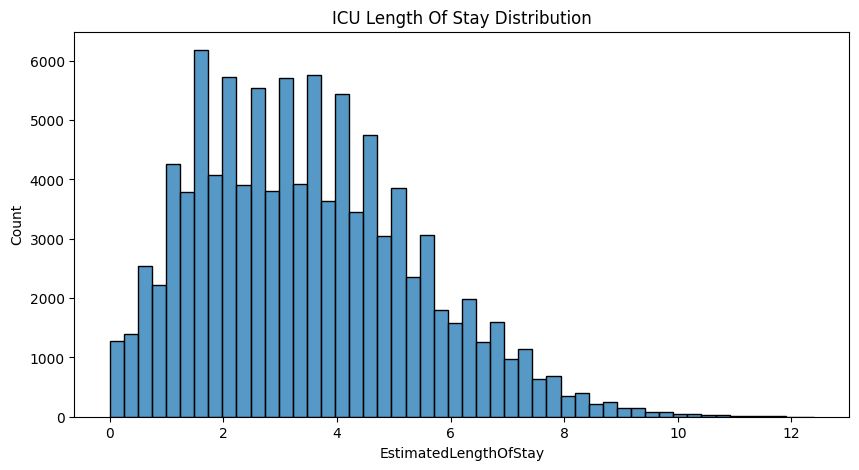

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(y, bins=50)

plt.title("ICU Length Of Stay Distribution")

plt.show()

In [15]:
y_log = np.log1p(y)

print(y_log.head())

0    1.547563
1    1.098612
2    1.960095
3    1.568616
4    1.435085
Name: EstimatedLengthOfStay, dtype: float64


In [16]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Feature Shape:")
print(X.shape)

Encoded Feature Shape:
(103248, 152862)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (82598, 152862)
Test Shape: (20650, 152862)


In [3]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("LOS Model Trained Successfully")

NameError: name 'XGBRegressor' is not defined

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import shap
import joblib

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/icu_data.csv")

print(df.shape)

(104557, 67)


In [3]:
df = df.drop_duplicates()

print(df.shape)

(104557, 67)


In [4]:
df = df[df["EstimatedLengthOfStay"] >= 0]

print(df.shape)

(103248, 67)


In [5]:
drop_cols = [
    "ID",
    "UHID",
    "IPNumber",
    "ICUChartDate",
    "UpdatedBy",
    "UpdatedDate",
    "Ward",
    "EstimatedMortalityRate"
]

drop_cols = [col for col in drop_cols if col in df.columns]

df.drop(columns=drop_cols, inplace=True)

print(df.shape)

(103248, 59)


In [6]:
categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(categorical_cols)

['MecanicalVentilation', 'SystemValue', 'DiagnosisValue', 'CreatedDate', 'DOB', 'Gender', 'AdmittingDoctor', 'AdmissionDate', 'CREATEDON', 'APACHE_WARD', 'CUSTOMERSTATUS', 'LOCATION', 'DISCHARGEDATE']


In [7]:
extra_drop_cols = [
    "SystemValue",
    "DiagnosisValue",
    "CreatedDate",
    "DOB",
    "AdmittingDoctor",
    "AdmissionDate",
    "CREATEDON",
    "APACHE_WARD",
    "CUSTOMERSTATUS",
    "LOCATION",
    "DISCHARGEDATE"
]

# Remove only existing columns

extra_drop_cols = [
    col for col in extra_drop_cols
    if col in df.columns
]

# Drop columns

df.drop(columns=extra_drop_cols, inplace=True)

print("Dropped Columns:")
print(extra_drop_cols)

print("\nUpdated Shape:")
print(df.shape)

Dropped Columns:
['SystemValue', 'DiagnosisValue', 'CreatedDate', 'DOB', 'AdmittingDoctor', 'AdmissionDate', 'CREATEDON', 'APACHE_WARD', 'CUSTOMERSTATUS', 'LOCATION', 'DISCHARGEDATE']

Updated Shape:
(103248, 48)


In [8]:
categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(categorical_cols)

['MecanicalVentilation', 'Gender']


In [9]:
from sklearn.impute import SimpleImputer

# Numerical columns
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Categorical columns
categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Median imputation for numerical columns
num_imputer = SimpleImputer(strategy='median')

df[numerical_cols] = num_imputer.fit_transform(
    df[numerical_cols]
)

# Most frequent imputation for categorical columns
if len(categorical_cols) > 0:

    cat_imputer = SimpleImputer(
        strategy='most_frequent'
    )

    df[categorical_cols] = cat_imputer.fit_transform(
        df[categorical_cols]
    )

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


In [10]:
target_col = "EstimatedLengthOfStay"

X = df.drop(columns=[target_col])

y = df[target_col]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (103248, 47)
Target Shape: (103248,)


In [11]:
y_log = np.log1p(y)

print(y_log.head())

0    1.547563
1    1.098612
2    1.960095
3    1.568616
4    1.435085
Name: EstimatedLengthOfStay, dtype: float64


In [12]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Feature Shape:")
print(X.shape)

Encoded Feature Shape:
(103248, 48)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (82598, 48)
Test Shape: (20650, 48)


In [14]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("LOS Model Trained Successfully")

LOS Model Trained Successfully


In [15]:
# Predict on test data

y_pred_log = xgb_model.predict(X_test)

# Convert back from log scale

y_pred = np.expm1(y_pred_log)

y_actual = np.expm1(y_test)

print(y_pred[:5])

[6.3047047 5.061829  2.5945206 2.0239496 1.2698326]


In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Evaluation metrics

mae = mean_absolute_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred
    )
)

r2 = r2_score(
    y_actual,
    y_pred
)

print("===== LOS MODEL PERFORMANCE =====")

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

===== LOS MODEL PERFORMANCE =====
MAE  : 0.48
RMSE : 0.70
R2   : 0.8670


In [17]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                   Feature  Importance
40                ApsScore    0.329158
45  MecanicalVentilation_b    0.176055
5                     FiO2    0.131603
6                      pO2    0.067656
30      PreICULengthOfStay    0.041348
32                  Origin    0.032637
18       IsGCSNotAvailable    0.029861
31           DiagnosisType    0.021961
33        EmergencySurgery    0.018549
19                 GCSEyes    0.016464
44              PERIOD_WID    0.016046
0                      Age    0.011732
28     MetastaticCarcinoma    0.008962
20               GCSVerbal    0.008831
34             Readmission    0.007388
38               CreatedBy    0.006999
46             Gender_Male    0.006919
43              LOCATIONID    0.005829
25                Leukemia    0.005456
37     AtmosphericPressure    0.005047


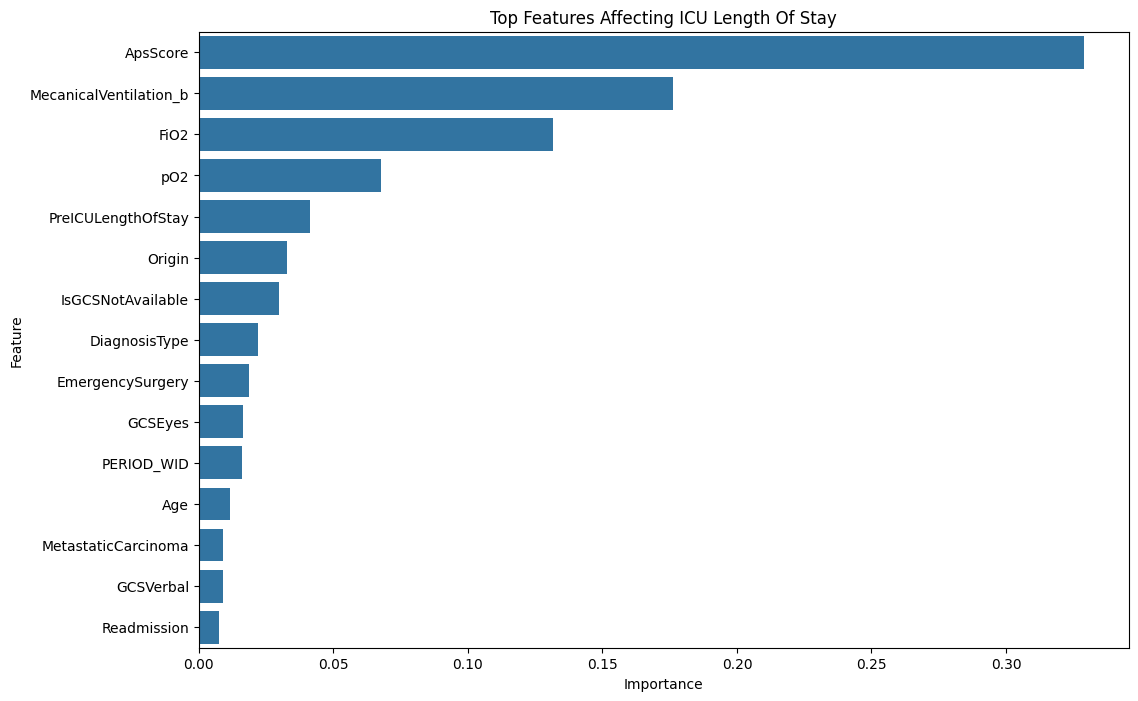

In [18]:
top_features = importance_df.head(15)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Affecting ICU Length Of Stay")

plt.show()

In [20]:
import shap

explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test)

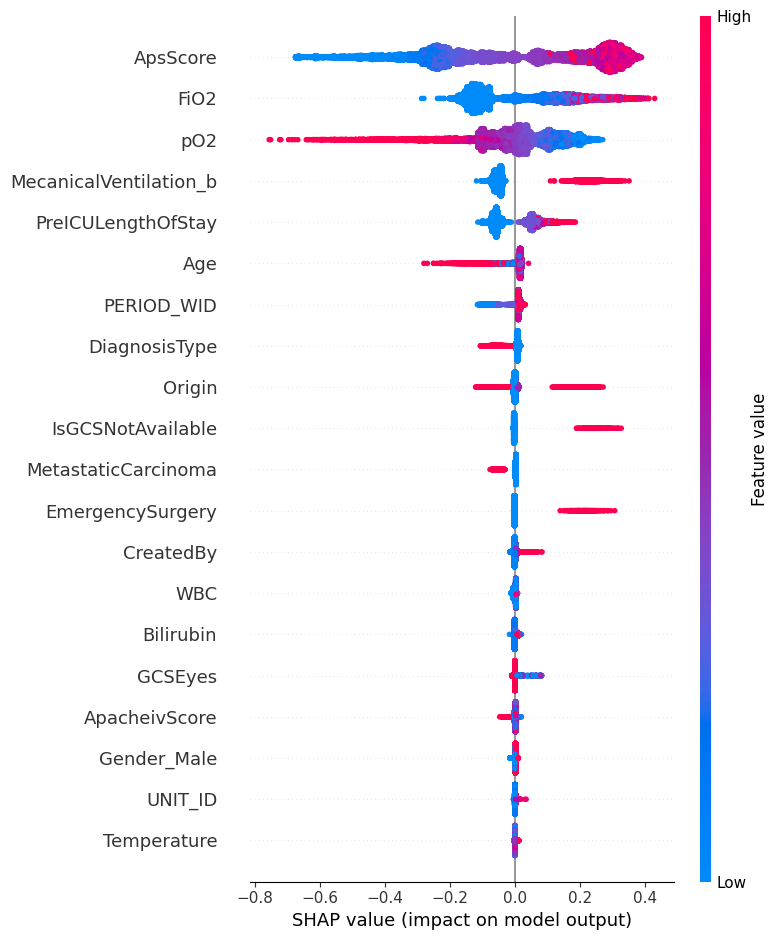

In [21]:
shap.summary_plot(
    shap_values,
    X_test
)

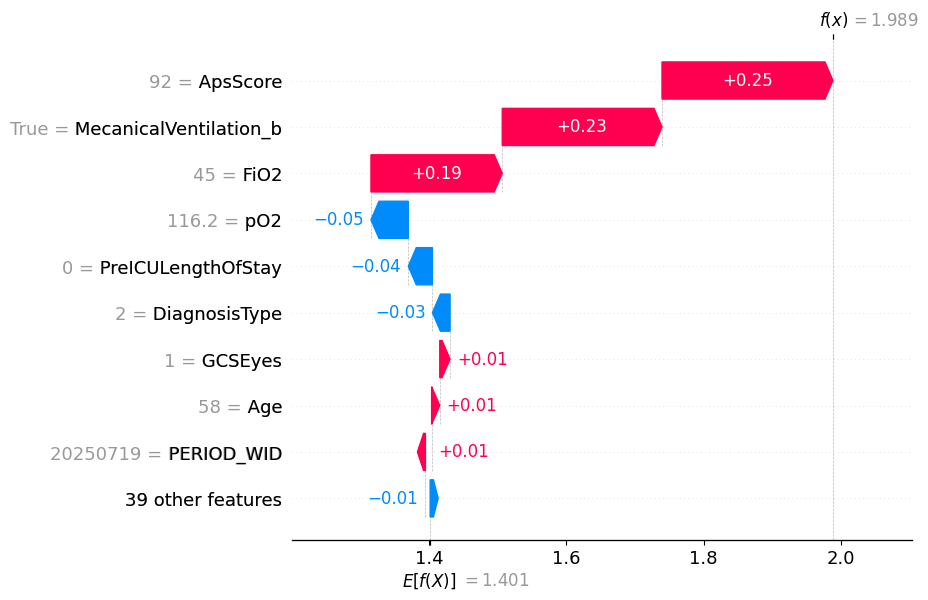

In [22]:
shap.plots.waterfall(
    shap_values[0]
)

In [23]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgb_los_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
print(df.columns.tolist())

['Age', 'Temperature', 'MeanArterialPressure', 'HeartRate', 'RespiratoryRate', 'FiO2', 'pO2', 'pCO2', 'ArterialpH', 'Sodium', 'UrineOutput', 'Creatinine', 'Urea', 'BSL', 'Albumin', 'Bilirubin', 'Hematocrit', 'WBC', 'IsGCSNotAvailable', 'GCSEyes', 'GCSVerbal', 'GCSMotor', 'MecanicalVentilation', 'CRF', 'Lymphoma', 'Cirrhosis', 'Leukemia', 'HepaticFailure', 'Immunosuppression', 'MetastaticCarcinoma', 'AIDS', 'PreICULengthOfStay', 'DiagnosisType', 'Origin', 'EmergencySurgery', 'Readmission', 'Thrombolysis', 'RespiratoryQuotient', 'AtmosphericPressure', 'CreatedBy', 'Gender', 'ApacheivScore', 'ApsScore', 'EstimatedLengthOfStay', 'UNIT_ID', 'RNK', 'LOCATIONID', 'PERIOD_WID']


In [25]:
X.columns.tolist()

['Age',
 'Temperature',
 'MeanArterialPressure',
 'HeartRate',
 'RespiratoryRate',
 'FiO2',
 'pO2',
 'pCO2',
 'ArterialpH',
 'Sodium',
 'UrineOutput',
 'Creatinine',
 'Urea',
 'BSL',
 'Albumin',
 'Bilirubin',
 'Hematocrit',
 'WBC',
 'IsGCSNotAvailable',
 'GCSEyes',
 'GCSVerbal',
 'GCSMotor',
 'CRF',
 'Lymphoma',
 'Cirrhosis',
 'Leukemia',
 'HepaticFailure',
 'Immunosuppression',
 'MetastaticCarcinoma',
 'AIDS',
 'PreICULengthOfStay',
 'DiagnosisType',
 'Origin',
 'EmergencySurgery',
 'Readmission',
 'Thrombolysis',
 'RespiratoryQuotient',
 'AtmosphericPressure',
 'CreatedBy',
 'ApacheivScore',
 'ApsScore',
 'UNIT_ID',
 'RNK',
 'LOCATIONID',
 'PERIOD_WID',
 'MecanicalVentilation_b',
 'Gender_Male',
 'Gender_Others']

In [26]:
feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "../models/feature_columns.pkl"
)

print("Feature Columns Saved Successfully")

Feature Columns Saved Successfully


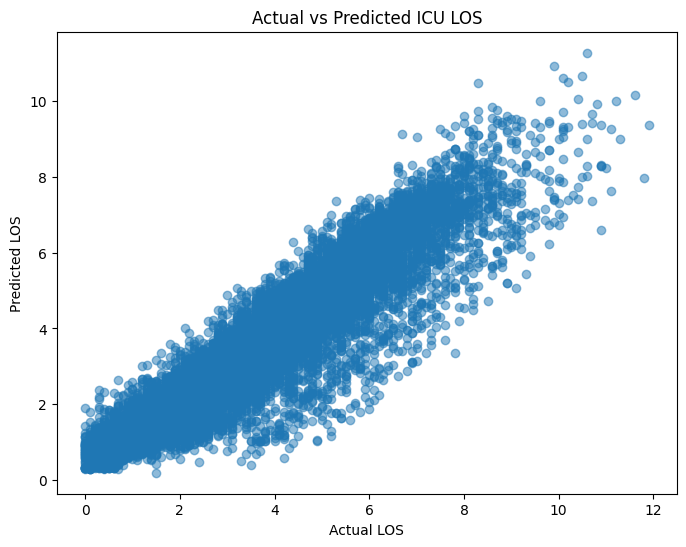

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual LOS")
plt.ylabel("Predicted LOS")

plt.title("Actual vs Predicted ICU LOS")

plt.show()